In [1]:
# ============================================================
# DATA3001 - Region Selection
# Global Drifter Program hourly dataset
#
# 目的：
# 比较三个候选 region：
# 1. Agulhas Current
# 2. Gulf Stream
# 3. Kuroshio Current
#
# 我们比较：
# - Total hourly observations
# - Unique drifters
# - Spatial coverage (1° × 1° grid)
# - Cells with >= 20 observations
# - Monthly / seasonal coverage
#
# 注意：
# Dataset 非常大（约 1.97 亿 observations）
# 所以我们采用 chunk-by-chunk 分块读取
# 绝对不要把整个 dataset 转成 pandas DataFrame
# ============================================================


# ---------------------------
# 1. Import packages
# ---------------------------
!pip install clouddrift
from clouddrift.datasets import gdp1h

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ---------------------------
# 2. Load GDP hourly dataset
# ---------------------------

ds = gdp1h()

print("Dataset loaded successfully")
print("Number of trajectories:", ds.sizes["traj"])
print("Number of observations:", ds.sizes["obs"])


# ---------------------------
# 3. 定义三个 candidate regions
#
# 注意：
# 这些是用于 preliminary screening 的 bounding boxes。
# 后续如果发现 coverage 不理想，可以再缩小或调整。
# ---------------------------

regions = {

    "Agulhas": {
        "lon_min": 20,
        "lon_max": 35,
        "lat_min": -40,
        "lat_max": -25
    },

    "Gulf Stream": {
        "lon_min": -75,
        "lon_max": -55,
        "lat_min": 30,
        "lat_max": 45
    },

    "Kuroshio": {
        "lon_min": 120,
        "lon_max": 145,
        "lat_min": 20,
        "lat_max": 40
    }
}


# ---------------------------
# 4. 为每一个 region 建立 1° × 1° grid
#
# histogram matrix 之后会统计：
# 每个 cell 有多少 observations
# ---------------------------

for name, r in regions.items():

    # 经度边界
    r["lon_bins"] = np.arange(
        r["lon_min"],
        r["lon_max"] + 1,
        1
    )

    # 纬度边界
    r["lat_bins"] = np.arange(
        r["lat_min"],
        r["lat_max"] + 1,
        1
    )

    # 初始化 grid observation count
    r["grid_counts"] = np.zeros(
        (
            len(r["lon_bins"]) - 1,
            len(r["lat_bins"]) - 1
        ),
        dtype=np.int64
    )

    # 总 observation 数
    r["n_obs"] = 0

    # 每个月 observation 数
    # index 0 = January
    # index 11 = December
    r["monthly_counts"] = np.zeros(
        12,
        dtype=np.int64
    )

    # 存放进入该区域的 trajectory index
    # 用 set 可以自动去重
    r["traj_indices"] = set()


# ---------------------------
# 5. 准备 trajectory boundaries
#
# GDP dataset 是 ragged trajectory structure：
# 一个 drifter 对应很多 observations。
#
# rowsize 告诉我们：
# 每一条 trajectory 有多少 observations。
# ---------------------------

rowsize = ds["rowsize"].values.astype(np.int64)

# cumulative end positions
traj_ends = np.cumsum(rowsize)

print("Sum of rowsize:", traj_ends[-1])
print("Dataset obs:", ds.sizes["obs"])


# ---------------------------
# 6. 设置 chunk size
#
# 一次只读取 500,000 observations
#
# 如果电脑内存比较大，也可以改成：
# 1_000_000
#
# 如果又崩溃：
# 改成 250_000
# ---------------------------

chunk_size = 500_000

n_obs_total = ds.sizes["obs"]

print("\nStarting chunked scan...")
print("Chunk size:", chunk_size)


# ---------------------------
# 7. 开始扫描整个 dataset
# ---------------------------

for start in range(0, n_obs_total, chunk_size):

    # 当前 chunk 的结束位置
    end = min(
        start + chunk_size,
        n_obs_total
    )

    # -----------------------
    # 只把当前 chunk 加载进内存
    # -----------------------

    lon = ds["lon"].isel(
        obs=slice(start, end)
    ).values

    lat = ds["lat"].isel(
        obs=slice(start, end)
    ).values

    time = ds["time"].isel(
        obs=slice(start, end)
    ).values


    # -----------------------
    # 把 time 转成月份
    #
    # datetime64[M]：
    # 转成月份编号
    # -----------------------

    months = (
        time.astype("datetime64[M]")
        .astype(int) % 12
    ) + 1


    # -----------------------
    # 对三个 regions 分别计算
    # -----------------------

    for name, r in regions.items():

        # 判断 observation 是否进入该 region
        mask = (
            (lon >= r["lon_min"]) &
            (lon <= r["lon_max"]) &
            (lat >= r["lat_min"]) &
            (lat <= r["lat_max"])
        )

        # 当前 chunk 中属于该 region 的数量
        current_n = np.count_nonzero(mask)

        # 加到累计 observation count
        r["n_obs"] += current_n


        # -----------------------
        # 如果这个 chunk 没有 region data
        # 就跳过后面的操作
        # -----------------------

        if current_n == 0:
            continue


        # -----------------------
        # 8. Spatial grid count
        # -----------------------

        region_lon = lon[mask]
        region_lat = lat[mask]

        H, _, _ = np.histogram2d(
            region_lon,
            region_lat,
            bins=[
                r["lon_bins"],
                r["lat_bins"]
            ]
        )

        # 累加到完整 grid matrix
        r["grid_counts"] += H.astype(np.int64)


        # -----------------------
        # 9. Monthly observation count
        # -----------------------

        region_months = months[mask]

        for month in range(1, 13):

            r["monthly_counts"][month - 1] += (
                np.count_nonzero(
                    region_months == month
                )
            )


        # -----------------------
        # 10. Unique drifter calculation
        #
        # mask 为 True 的 global observation indices
        # -----------------------

        local_indices = np.flatnonzero(mask)

        global_indices = (
            local_indices + start
        )

        # 根据 observation index 找到所属 trajectory
        #
        # traj_ends 类似：
        # [10000, 18000, 27000, ...]
        #
        # searchsorted 可以判断该 observation
        # 属于第几条 trajectory
        traj_indices = np.searchsorted(
            traj_ends,
            global_indices,
            side="right"
        )

        # 当前 chunk 内去重
        unique_traj = np.unique(
            traj_indices
        )

        # 加入 set
        r["traj_indices"].update(
            unique_traj.tolist()
        )


    # -----------------------
    # 每处理 5,000,000 条打印一次进度
    # -----------------------

    if (
        start == 0 or
        end % 5_000_000 < chunk_size or
        end == n_obs_total
    ):

        progress = (
            end /
            n_obs_total *
            100
        )

        print(
            f"Processed {end:,} / "
            f"{n_obs_total:,} "
            f"({progress:.1f}%)"
        )


# ---------------------------
# 11. Scan finished
# ---------------------------

print("\n================================")
print("SCAN FINISHED")
print("================================")


for name, r in regions.items():

    print("\n", name)

    print(
        "Observations:",
        f"{r['n_obs']:,}"
    )

    print(
        "Unique drifters:",
        len(r["traj_indices"])
    )

Dataset loaded successfully
Number of trajectories: 19396
Number of observations: 197214787
Sum of rowsize: 197214787
Dataset obs: 197214787

Starting chunked scan...
Chunk size: 500000
Processed 500,000 / 197,214,787 (0.3%)
Processed 5,000,000 / 197,214,787 (2.5%)
Processed 10,000,000 / 197,214,787 (5.1%)
Processed 15,000,000 / 197,214,787 (7.6%)
Processed 20,000,000 / 197,214,787 (10.1%)
Processed 25,000,000 / 197,214,787 (12.7%)
Processed 30,000,000 / 197,214,787 (15.2%)
Processed 35,000,000 / 197,214,787 (17.7%)
Processed 40,000,000 / 197,214,787 (20.3%)
Processed 45,000,000 / 197,214,787 (22.8%)
Processed 50,000,000 / 197,214,787 (25.4%)
Processed 55,000,000 / 197,214,787 (27.9%)
Processed 60,000,000 / 197,214,787 (30.4%)
Processed 65,000,000 / 197,214,787 (33.0%)
Processed 70,000,000 / 197,214,787 (35.5%)
Processed 75,000,000 / 197,214,787 (38.0%)
Processed 80,000,000 / 197,214,787 (40.6%)
Processed 85,000,000 / 197,214,787 (43.1%)
Processed 90,000,000 / 197,214,787 (45.6%)
Proce

In [3]:
# ============================================================
# PART 2
# 根据上一步保存的结果计算：
#
# - Occupied grid cells
# - Cells with >= 20 observations
# - Spatial coverage %
# - Reliable coverage %
# - Summer / Autumn / Winter / Spring observations
#
# ============================================================


# ---------------------------
# 1. 定义 seasonal count function
#
# 注意：
# Agulhas 在南半球
#
# Gulf Stream / Kuroshio 在北半球
#
# 所以 season 定义不同
# ---------------------------

def calculate_seasons(
    monthly_counts,
    hemisphere
):

    # monthly_counts:
    #
    # index:
    # 0 = Jan
    # 1 = Feb
    # ...
    # 11 = Dec


    if hemisphere == "south":

        # Southern Hemisphere

        summer = (
            monthly_counts[11] +  # Dec
            monthly_counts[0] +   # Jan
            monthly_counts[1]     # Feb
        )

        autumn = (
            monthly_counts[2] +   # Mar
            monthly_counts[3] +   # Apr
            monthly_counts[4]     # May
        )

        winter = (
            monthly_counts[5] +   # Jun
            monthly_counts[6] +   # Jul
            monthly_counts[7]     # Aug
        )

        spring = (
            monthly_counts[8] +   # Sep
            monthly_counts[9] +   # Oct
            monthly_counts[10]    # Nov
        )


    else:

        # Northern Hemisphere

        winter = (
            monthly_counts[11] +
            monthly_counts[0] +
            monthly_counts[1]
        )

        spring = (
            monthly_counts[2] +
            monthly_counts[3] +
            monthly_counts[4]
        )

        summer = (
            monthly_counts[5] +
            monthly_counts[6] +
            monthly_counts[7]
        )

        autumn = (
            monthly_counts[8] +
            monthly_counts[9] +
            monthly_counts[10]
        )


    return {
        "Summer": int(summer),
        "Autumn": int(autumn),
        "Winter": int(winter),
        "Spring": int(spring)
    }


# ---------------------------
# 2. Hemisphere information
# ---------------------------

hemispheres = {
    "Agulhas": "south",
    "Gulf Stream": "north",
    "Kuroshio": "north"
}


# ---------------------------
# 3. 建立 summary list
# ---------------------------

summary_rows = []


for name, r in regions.items():

    H = r["grid_counts"]


    # -----------------------
    # 总 grid cells
    # -----------------------

    total_cells = H.size


    # -----------------------
    # 有至少 1 observation 的 cells
    # -----------------------

    occupied_cells = np.count_nonzero(
        H > 0
    )


    # -----------------------
    # 至少 20 observations 的 cells
    #
    # 老师 example 中用了：
    # cells with N >= 20
    # -----------------------

    good_cells = np.count_nonzero(
        H >= 20
    )


    # -----------------------
    # Spatial coverage
    # -----------------------

    spatial_coverage = (
        occupied_cells /
        total_cells *
        100
    )


    # -----------------------
    # Reliable coverage
    #
    # 定义为：
    # N >= 20 的 cells 占全部 cells 百分比
    # -----------------------

    reliable_coverage = (
        good_cells /
        total_cells *
        100
    )


    # -----------------------
    # Seasonal counts
    # -----------------------

    seasons = calculate_seasons(
        r["monthly_counts"],
        hemispheres[name]
    )


    # -----------------------
    # 加到 summary
    # -----------------------

    summary_rows.append({

        "Region":
            name,

        "Total observations":
            r["n_obs"],

        "Unique drifters":
            len(r["traj_indices"]),

        "Total 1° cells":
            total_cells,

        "Occupied cells":
            occupied_cells,

        "Cells >= 20 obs":
            good_cells,

        "Spatial coverage %":
            spatial_coverage,

        "Reliable coverage %":
            reliable_coverage,

        "Summer observations":
            seasons["Summer"],

        "Autumn observations":
            seasons["Autumn"],

        "Winter observations":
            seasons["Winter"],

        "Spring observations":
            seasons["Spring"]
    })


# ---------------------------
# 4. 转成 DataFrame
# ---------------------------

summary = pd.DataFrame(
    summary_rows
)


# ---------------------------
# 5. 显示结果
# ---------------------------

summary

,Region,Total observations,Unique drifters,Total 1° cells,Occupied cells,Cells >= 20 obs,Spatial coverage %,Reliable coverage %,Summer observations,Autumn observations,Winter observations,Spring observations
0,Agulhas,720930,494,225,135,134,60.0,59.555556,157905,203467,182003,177555
1,Gulf Stream,3634598,1072,300,282,282,94.0,94.000000,990550,1050211,801586,792251
2,Kuroshio,3238428,1248,500,451,442,90.2,88.400000,824496,943907,791513,678512


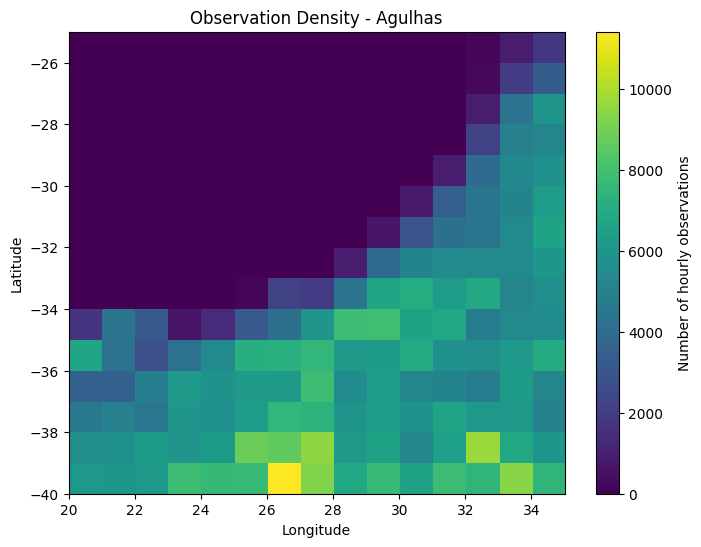

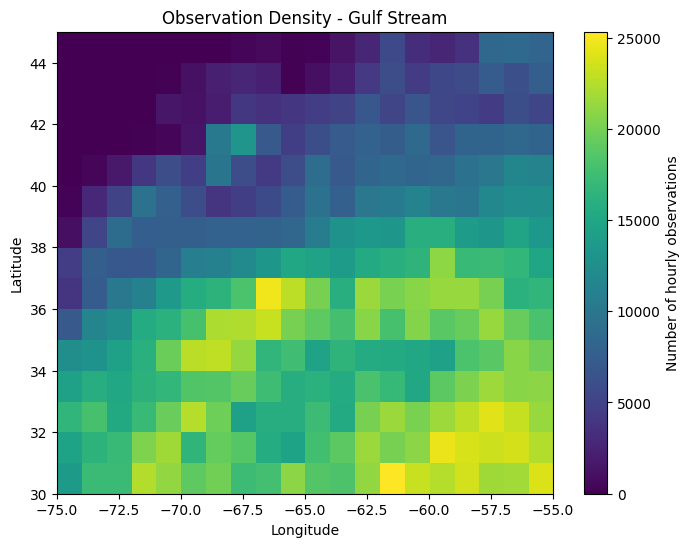

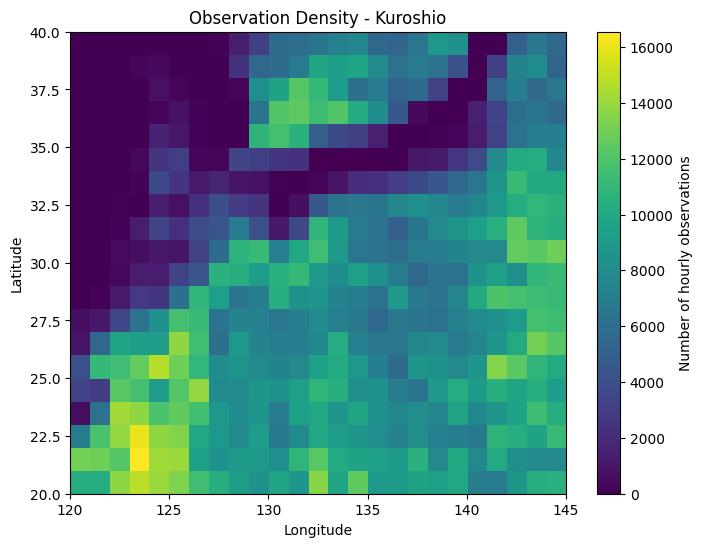

In [4]:
# ============================================================
# PART 3
# Plot observation density maps
#
# 每张图表示：
# 每一个 1° × 1° grid cell
# 有多少 hourly GDP observations
# ============================================================


for name, r in regions.items():

    H = r["grid_counts"]


    # -----------------------
    # 建立新的 figure
    # -----------------------

    plt.figure(
        figsize=(8, 6)
    )


    # -----------------------
    # Plot grid observation density
    #
    # H.T：
    # histogram2d 的输出需要 transpose
    # 才能和 lat/lon 正确对应
    # -----------------------

    plt.imshow(
        H.T,
        origin="lower",
        aspect="auto",
        extent=[
            r["lon_min"],
            r["lon_max"],
            r["lat_min"],
            r["lat_max"]
        ]
    )


    # -----------------------
    # Color bar
    # -----------------------

    plt.colorbar(
        label="Number of hourly observations"
    )


    # -----------------------
    # Labels
    # -----------------------

    plt.xlabel(
        "Longitude"
    )

    plt.ylabel(
        "Latitude"
    )


    plt.title(
        f"Observation Density - {name}"
    )


    # -----------------------
    # 显示
    # -----------------------

    plt.show()

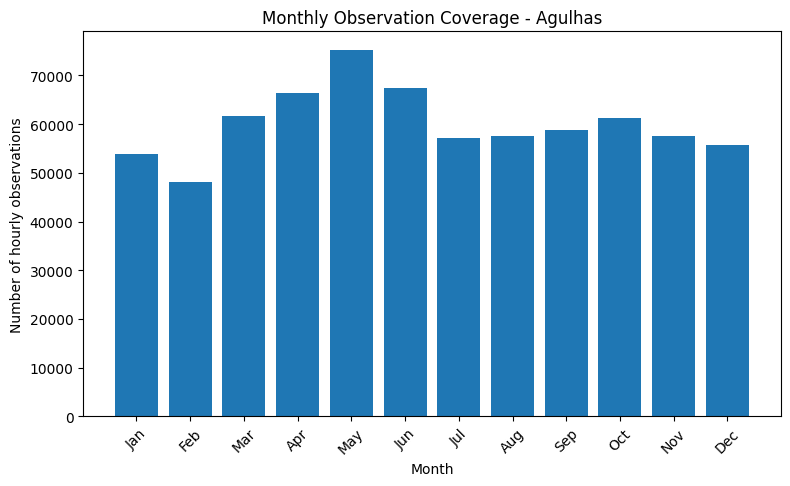

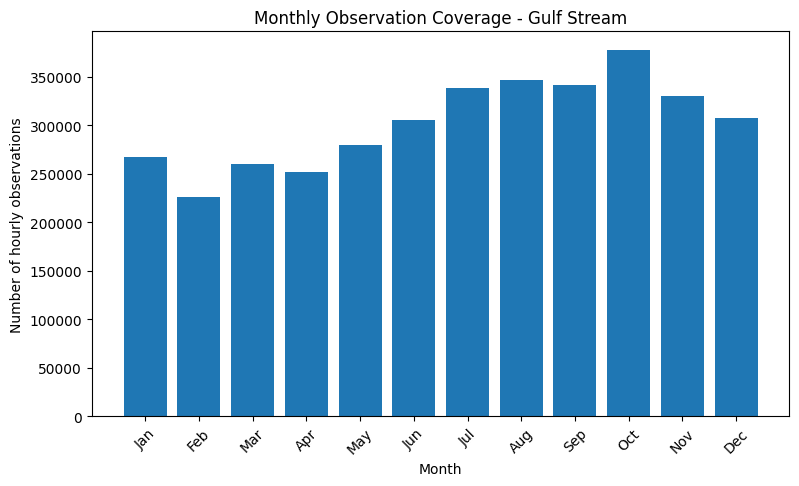

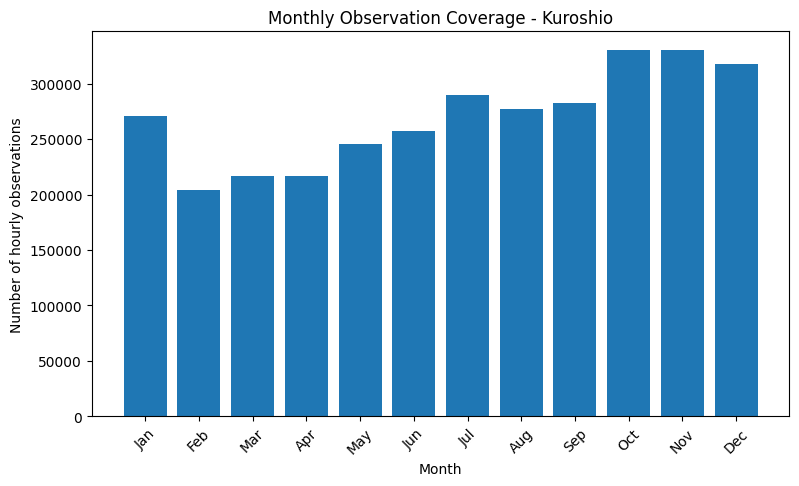

In [5]:
# ============================================================
# PART 4
# Compare monthly observation coverage
#
# 用来判断：
# 每个月是否都有足够 observations
#
# 因为我们最终想研究 seasonal circulation
# ============================================================


month_names = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec"
]


for name, r in regions.items():

    plt.figure(
        figsize=(9, 5)
    )


    plt.bar(
        month_names,
        r["monthly_counts"]
    )


    plt.xlabel(
        "Month"
    )

    plt.ylabel(
        "Number of hourly observations"
    )


    plt.title(
        f"Monthly Observation Coverage - {name}"
    )


    plt.xticks(
        rotation=45
    )


    plt.show()

In [6]:
# ============================================================
# PART 5
# Seasonal comparison table
# ============================================================


season_rows = []


for name, r in regions.items():

    seasons = calculate_seasons(
        r["monthly_counts"],
        hemispheres[name]
    )


    season_rows.append({

        "Region": name,

        "Summer":
            seasons["Summer"],

        "Autumn":
            seasons["Autumn"],

        "Winter":
            seasons["Winter"],

        "Spring":
            seasons["Spring"]
    })


season_table = pd.DataFrame(
    season_rows
)


season_table

,Region,Summer,Autumn,Winter,Spring
0,Agulhas,157905,203467,182003,177555
1,Gulf Stream,990550,1050211,801586,792251
2,Kuroshio,824496,943907,791513,678512


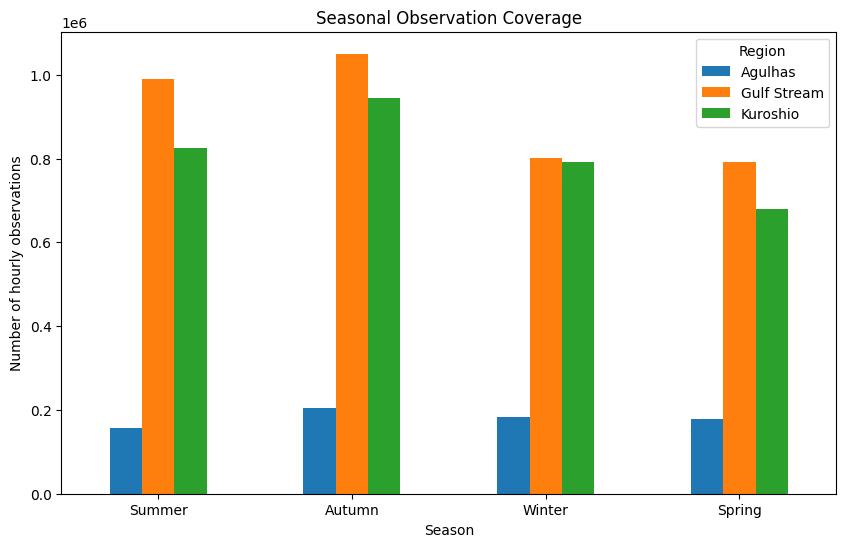

In [7]:
# ============================================================
# Seasonal observation comparison
# ============================================================


season_table_plot = (
    season_table
    .set_index("Region")
    .T
)


season_table_plot.plot(
    kind="bar",
    figsize=(10, 6)
)


plt.xlabel(
    "Season"
)

plt.ylabel(
    "Number of hourly observations"
)

plt.title(
    "Seasonal Observation Coverage"
)

plt.xticks(
    rotation=0
)

plt.show()

In [8]:
# ============================================================
# PART 6
# Calculate seasonal balance
#
# seasonal_balance 越接近 1：
# 四季 observations 越均衡
#
# 越接近 0：
# 四季 sampling 越不均衡
# ============================================================


season_balance_list = []


for name, r in regions.items():

    seasons = calculate_seasons(
        r["monthly_counts"],
        hemispheres[name]
    )


    values = np.array(
        list(seasons.values()),
        dtype=float
    )


    seasonal_balance = (
        values.min() /
        values.max()
    )


    season_balance_list.append({
        "Region":
            name,

        "Seasonal balance":
            seasonal_balance
    })


season_balance_df = pd.DataFrame(
    season_balance_list
)


season_balance_df

,Region,Seasonal balance
0,Agulhas,0.776072
1,Gulf Stream,0.754373
2,Kuroshio,0.718834


In [9]:
# ============================================================
# PART 7
# Final Region Selection Table
# ============================================================


final_comparison = summary.merge(
    season_balance_df,
    on="Region"
)


# 设置显示格式
pd.set_option(
    "display.max_columns",
    None
)


final_comparison

,Region,Total observations,Unique drifters,Total 1° cells,Occupied cells,Cells >= 20 obs,Spatial coverage %,Reliable coverage %,Summer observations,Autumn observations,Winter observations,Spring observations,Seasonal balance
0,Agulhas,720930,494,225,135,134,60.0,59.555556,157905,203467,182003,177555,0.776072
1,Gulf Stream,3634598,1072,300,282,282,94.0,94.000000,990550,1050211,801586,792251,0.754373
2,Kuroshio,3238428,1248,500,451,442,90.2,88.400000,824496,943907,791513,678512,0.718834


In [10]:
# ============================================================
# Save region comparison table
# ============================================================


final_comparison.to_csv(
    "DATA3001_region_selection.csv",
    index=False
)


print(
    "Saved as DATA3001_region_selection.csv"
)

Saved as DATA3001_region_selection.csv


In [11]:
# ============================================================
# PART 8
# Mean Circulation Analysis
#
# 假设最终选择：
# Agulhas Current
#
# 如果最终选 Gulf Stream / Kuroshio，
# 只需要修改下面四个经纬度即可。
# ============================================================


# ---------------------------
# 1. Selected region
# ---------------------------

selected_name = "Agulhas"

lon_min = 20
lon_max = 35

lat_min = -40
lat_max = -25


# ---------------------------
# 2. 创建 1° grid
# ---------------------------

lon_bins = np.arange(
    lon_min,
    lon_max + 1,
    1
)

lat_bins = np.arange(
    lat_min,
    lat_max + 1,
    1
)


# ---------------------------
# 3. Grid size
# ---------------------------

n_lon = (
    len(lon_bins) - 1
)

n_lat = (
    len(lat_bins) - 1
)


# ---------------------------
# 4. 初始化统计量
#
# 为了计算 mean velocity：
#
# mean_u = sum_u / n
# mean_v = sum_v / n
#
# 我们不需要保存所有 observations
# ---------------------------

count_grid = np.zeros(
    (n_lon, n_lat)
)

sum_u_grid = np.zeros(
    (n_lon, n_lat)
)

sum_v_grid = np.zeros(
    (n_lon, n_lat)
)

sum_u2_grid = np.zeros(
    (n_lon, n_lat)
)

sum_v2_grid = np.zeros(
    (n_lon, n_lat)
)


# ---------------------------
# 5. Chunk scanning
# ---------------------------

chunk_size = 500_000

n_total = ds.sizes["obs"]


for start in range(
    0,
    n_total,
    chunk_size
):

    end = min(
        start + chunk_size,
        n_total
    )


    # 当前 chunk
    lon = ds["lon"].isel(
        obs=slice(start, end)
    ).values

    lat = ds["lat"].isel(
        obs=slice(start, end)
    ).values

    u = ds["ve"].isel(
        obs=slice(start, end)
    ).values

    v = ds["vn"].isel(
        obs=slice(start, end)
    ).values


    # -----------------------
    # Region mask
    # -----------------------

    mask = (
        (lon >= lon_min) &
        (lon <= lon_max) &
        (lat >= lat_min) &
        (lat <= lat_max) &
        np.isfinite(u) &
        np.isfinite(v)
    )


    # 如果没有 region observations
    if not np.any(mask):
        continue


    region_lon = lon[mask]
    region_lat = lat[mask]

    region_u = u[mask]
    region_v = v[mask]


    # -----------------------
    # Observation count
    # -----------------------

    H_count, _, _ = np.histogram2d(
        region_lon,
        region_lat,
        bins=[
            lon_bins,
            lat_bins
        ]
    )


    count_grid += H_count


    # -----------------------
    # Sum of u
    # -----------------------

    H_u, _, _ = np.histogram2d(
        region_lon,
        region_lat,
        bins=[
            lon_bins,
            lat_bins
        ],
        weights=region_u
    )


    sum_u_grid += H_u


    # -----------------------
    # Sum of v
    # -----------------------

    H_v, _, _ = np.histogram2d(
        region_lon,
        region_lat,
        bins=[
            lon_bins,
            lat_bins
        ],
        weights=region_v
    )


    sum_v_grid += H_v


    # -----------------------
    # Sum of u² / v²
    #
    # 用于之后计算 SD / SE
    # -----------------------

    H_u2, _, _ = np.histogram2d(
        region_lon,
        region_lat,
        bins=[
            lon_bins,
            lat_bins
        ],
        weights=region_u ** 2
    )


    H_v2, _, _ = np.histogram2d(
        region_lon,
        region_lat,
        bins=[
            lon_bins,
            lat_bins
        ],
        weights=region_v ** 2
    )


    sum_u2_grid += H_u2
    sum_v2_grid += H_v2


    # progress
    if (
        start == 0 or
        end % 10_000_000 < chunk_size or
        end == n_total
    ):

        print(
            f"Processed "
            f"{end:,} / "
            f"{n_total:,}"
        )


print(
    "Mean circulation scan finished."
)

Processed 500,000 / 197,214,787
Processed 10,000,000 / 197,214,787
Processed 40,000,000 / 197,214,787
Processed 80,000,000 / 197,214,787
Processed 90,000,000 / 197,214,787
Processed 110,000,000 / 197,214,787
Processed 120,000,000 / 197,214,787
Processed 160,000,000 / 197,214,787
Processed 190,000,000 / 197,214,787
Mean circulation scan finished.


In [13]:
# ============================================================
# PART 9
# Calculate mean velocity and uncertainty
# ============================================================


# 防止除以 0
valid = (
    count_grid > 0
)


# 初始化
mean_u = np.full(
    count_grid.shape,
    np.nan
)

mean_v = np.full(
    count_grid.shape,
    np.nan
)


# ---------------------------
# Mean velocity
# ---------------------------

mean_u[valid] = (
    sum_u_grid[valid] /
    count_grid[valid]
)

mean_v[valid] = (
    sum_v_grid[valid] /
    count_grid[valid]
)


# ---------------------------
# Mean current speed
#
# speed = sqrt(u² + v²)
# ---------------------------

mean_speed = np.sqrt(
    mean_u ** 2 +
    mean_v ** 2
)


# ---------------------------
# Variance
#
# Var(X) =
# E(X²) - E(X)²
# ---------------------------

var_u = np.full(
    count_grid.shape,
    np.nan
)

var_v = np.full(
    count_grid.shape,
    np.nan
)


var_u[valid] = (
    sum_u2_grid[valid] /
    count_grid[valid]
) - (
    mean_u[valid] ** 2
)


var_v[valid] = (
    sum_v2_grid[valid] /
    count_grid[valid]
) - (
    mean_v[valid] ** 2
)


# 防止 numerical precision 导致 tiny negative values
var_u = np.maximum(
    var_u,
    0
)

var_v = np.maximum(
    var_v,
    0
)


# ---------------------------
# Standard deviation
# ---------------------------

sd_u = np.sqrt(
    var_u
)

sd_v = np.sqrt(
    var_v
)


# ---------------------------
# Standard Error
#
# SE = SD / sqrt(n)
# ---------------------------

se_u = np.full(
    count_grid.shape,
    np.nan
)

se_v = np.full(
    count_grid.shape,
    np.nan
)


se_u[valid] = (
    sd_u[valid] /
    np.sqrt(
        count_grid[valid]
    )
)

se_v[valid] = (
    sd_v[valid] /
    np.sqrt(
        count_grid[valid]
    )
)

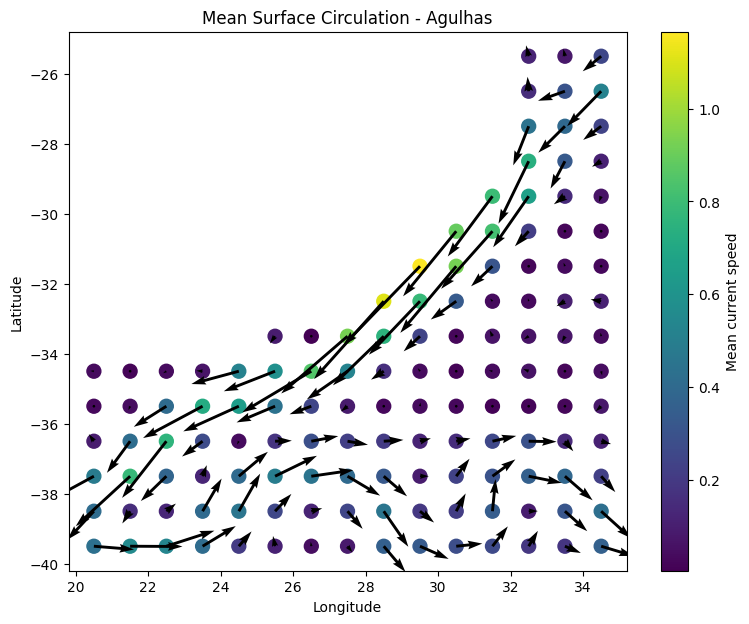

In [14]:
# ============================================================
# PART 10
# Plot Mean Surface Circulation
# ============================================================


# ---------------------------
# 只保留 N >= 20 cells
# ---------------------------

good = (
    count_grid >= 20
)


# ---------------------------
# Grid cell centres
# ---------------------------

lon_centres = (
    lon_bins[:-1] +
    lon_bins[1:]
) / 2


lat_centres = (
    lat_bins[:-1] +
    lat_bins[1:]
) / 2


LON, LAT = np.meshgrid(
    lon_centres,
    lat_centres,
    indexing="ij"
)


# ---------------------------
# Plot
# ---------------------------

plt.figure(
    figsize=(9, 7)
)


# Background = mean speed
plt.scatter(
    LON[good],
    LAT[good],
    c=mean_speed[good],
    s=100
)


plt.colorbar(
    label="Mean current speed"
)


# Arrows = direction
plt.quiver(
    LON[good],
    LAT[good],
    mean_u[good],
    mean_v[good]
)


plt.xlabel(
    "Longitude"
)

plt.ylabel(
    "Latitude"
)


plt.title(
    f"Mean Surface Circulation - {selected_name}"
)


plt.show()